In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ramyakondru/test-csv/test.csv.xlsx
/kaggle/input/datasets/ramyakondru/liver-patient-dataset-csv/Liver Patient Dataset (LPD)_train.csv


## Loading Liver Disease Dataset

The dataset contains patient records with liver function test (LFT) parameters.

These blood parameters are used to train a machine learning model to identify potential liver disease risk.

In [2]:
import pandas as pd

file_path = "/kaggle/input/datasets/ramyakondru/liver-patient-dataset-csv/Liver Patient Dataset (LPD)_train.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

print("Shape:", df.shape)

df.head()

Shape: (30691, 11)


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4    Alkphos Alkaline Phosphotase         29895 non-null  float64
 5    Sgpt Alamine Aminotransferase        30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8    ALB Albumin                          30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [4]:
df.isnull().sum()

Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(11323)

## Removing Duplicate Records

Duplicate patient records can introduce bias into the machine learning model.

We remove duplicate rows to ensure that each patient record contributes independently to model training.

In [6]:
# Remove duplicate records

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (19368, 11)


## Handling Missing Values

Missing laboratory values are common in medical datasets.

For preprocessing:
- Numerical blood parameters are filled using median values.
- Categorical values such as gender are filled using the most frequent category (mode).

This prevents data loss while maintaining the dataset size.

In [7]:
# Fill numerical missing values with median

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())


# Fill categorical missing values with mode

df["Gender of the patient"] = df["Gender of the patient"].fillna(
    df["Gender of the patient"].mode()[0]
)


# Check missing values after filling

df.isnull().sum()

Age of the patient                      0
Gender of the patient                   0
Total Bilirubin                         0
Direct Bilirubin                        0
 Alkphos Alkaline Phosphotase           0
 Sgpt Alamine Aminotransferase          0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
 ALB Albumin                            0
A/G Ratio Albumin and Globulin Ratio    0
Result                                  0
dtype: int64

## Renaming Features

The original dataset contains long feature names.

We rename the columns into shorter and meaningful names for easier analysis and model development.

In [8]:
df.columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "ALT",
    "AST",
    "Total_Proteins",
    "Albumin",
    "Albumin_Globulin_Ratio",
    "Target"
]

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,ALT,AST,Total_Proteins,Albumin,Albumin_Globulin_Ratio,Target
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [9]:
df.shape

(19368, 11)

## Target Distribution Analysis

The target variable represents whether a patient has liver disease or not.

Understanding the class distribution helps us identify possible class imbalance before model training.

In [10]:
df['Target'].value_counts()

Target
1    13811
2     5557
Name: count, dtype: int64

## Target Distribution Visualization

Visualizing the target distribution helps us understand the balance between liver disease and non-liver disease cases.

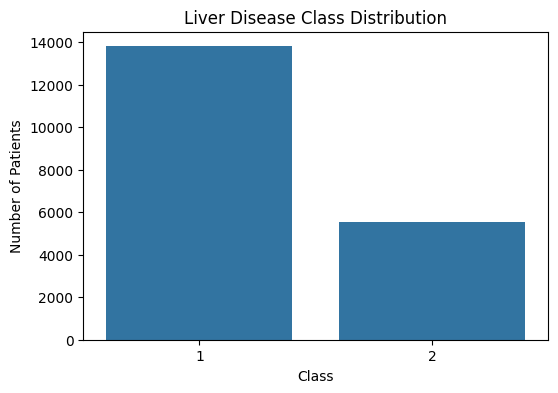

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="Target",
    data=df
)

plt.title("Liver Disease Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

## Target Label Encoding

The original dataset represents the target as:

- 1: Liver Disease
- 2: No Liver Disease

For binary classification, we convert it into:

- 1: Liver Disease
- 0: No Liver Disease

In [12]:
# Convert target labels

df["Target"] = df["Target"].map({
    1: 1,
    2: 0
})

df["Target"].value_counts()

Target
1    13811
0     5557
Name: count, dtype: int64

## Encoding Categorical Features

Machine learning models require numerical input.

The Gender feature contains categorical values, so we convert it into numerical form:

- Male → 1
- Female → 0

In [13]:
# Encode Gender column

df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,ALT,AST,Total_Proteins,Albumin,Albumin_Globulin_Ratio,Target
0,65.0,0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,1,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,1,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,1,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,1,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


## Correlation Analysis

Correlation analysis helps us understand relationships between blood parameters and the target variable.

It helps identify:
- Important features
- Relationships between laboratory values
- Possible feature redundancy

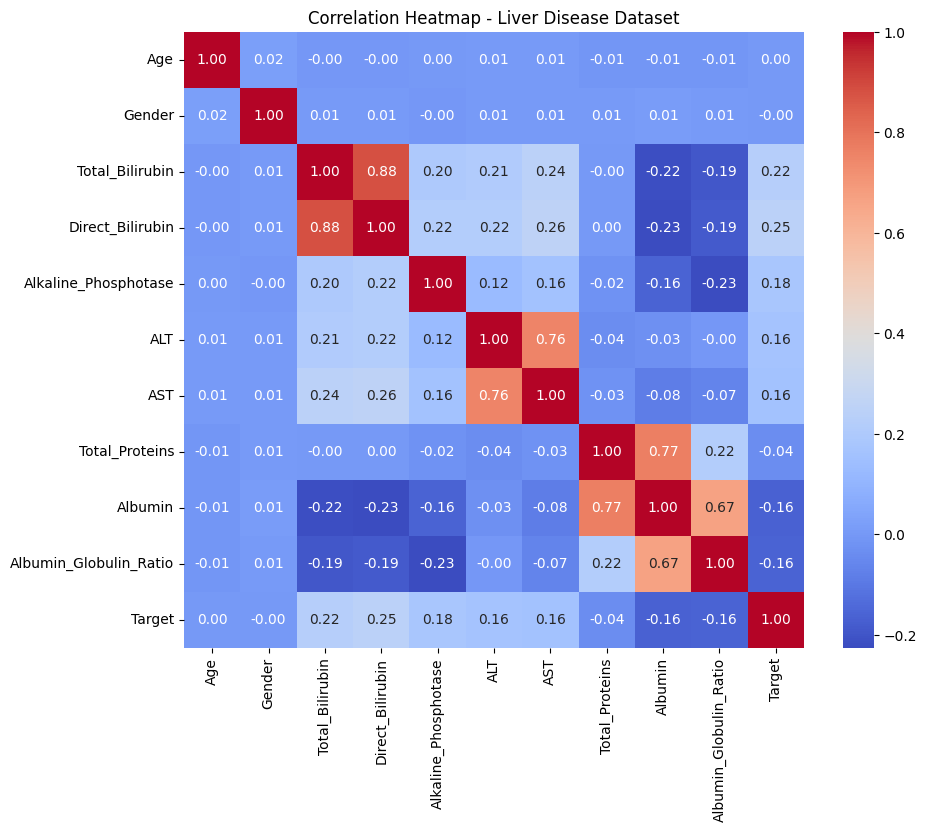

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Liver Disease Dataset")

plt.show()

## Feature and Target Separation

The dataset contains blood report parameters as input features and the liver disease label as the target.

We separate:
- X: Blood parameters used for prediction
- y: Liver disease outcome

In [15]:
# Separate features and target

X = df.drop("Target", axis=1)
y = df["Target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (19368, 10)
Target shape: (19368,)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,ALT,AST,Total_Proteins,Albumin,Albumin_Globulin_Ratio
0,65.0,0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90
1,62.0,1,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74
2,62.0,1,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89
3,58.0,1,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00
4,72.0,1,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15494, 10)
Testing data: (3874, 10)


## Feature Scaling

Blood report parameters have different numerical ranges.

StandardScaler transforms features so that:
- Mean = 0
- Standard deviation = 1

The scaler is fitted only on training data to prevent data leakage.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (15494, 10)
Scaled testing data: (3874, 10)


## Model Training - Logistic Regression

Logistic Regression is used as a baseline classification model.

It predicts whether a patient has liver disease based on blood report parameters.

Classes:
- 1 → Liver Disease
- 0 → No Liver Disease

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000
)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7214765100671141

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.18      0.27      1112
           1       0.74      0.94      0.83      2762

    accuracy                           0.72      3874
   macro avg       0.64      0.56      0.55      3874
weighted avg       0.68      0.72      0.67      3874



## Confusion Matrix - Logistic Regression

A confusion matrix helps analyze:
- Correct predictions
- False alarms
- Missed disease cases

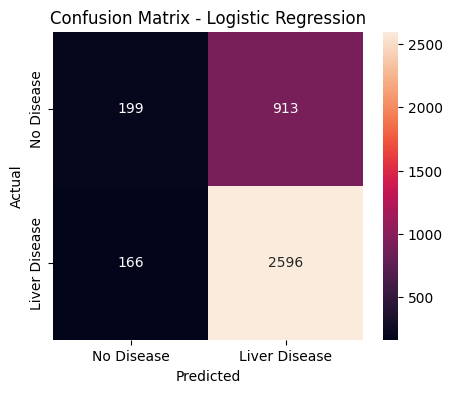

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Liver Disease"],
    yticklabels=["No Disease", "Liver Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Logistic Regression with Class Balancing

The dataset contains more liver disease samples than healthy samples.

To reduce bias toward the majority class, we use class weights.

The model gives more importance to minority class examples during training.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression with balanced class weights

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Train
lr_balanced.fit(X_train_scaled, y_train)

# Predict
y_pred_lr_balanced = lr_balanced.predict(X_test_scaled)

# Evaluate

print("Accuracy:", accuracy_score(y_test, y_pred_lr_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_balanced))

Accuracy: 0.6463603510583377

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.87      0.59      1112
           1       0.91      0.56      0.69      2762

    accuracy                           0.65      3874
   macro avg       0.68      0.71      0.64      3874
weighted avg       0.78      0.65      0.66      3874



In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9976768198244709

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1112
           1       1.00      1.00      1.00      2762

    accuracy                           1.00      3874
   macro avg       1.00      1.00      1.00      3874
weighted avg       1.00      1.00      1.00      3874



## Feature Importance Analysis

Random Forest provides feature importance scores.

This helps us understand which blood parameters contribute most to liver disease prediction.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Alkaline_Phosphotase,0.163786
6,AST,0.155838
5,ALT,0.151020
2,Total_Bilirubin,0.120600
8,Albumin,0.113018
7,Total_Proteins,0.110232
9,Albumin_Globulin_Ratio,0.098944
3,Direct_Bilirubin,0.081617
0,Age,0.004365
1,Gender,0.000579


## Cross Validation

A single train-test split may not always represent the true model performance.

We use 5-fold cross validation to evaluate whether the model consistently performs well on different subsets of the data.

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cv_scores = cross_val_score(
    rf_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.99612803 0.99819308 0.99483738 0.99715982 0.99870901]
Average CV Accuracy: 0.9970054656084424


## Final Random Forest Model

Random Forest does not require feature scaling because tree-based models split data based on feature thresholds.

We retrain the final model using the original feature values.

In [24]:
from sklearn.ensemble import RandomForestClassifier

final_liver_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_liver_model.fit(X_train, y_train)

print("Final Random Forest model trained successfully")

Final Random Forest model trained successfully


## Saving the Final Liver Disease Model

The trained Random Forest model is saved so that it can be integrated into the AI Blood Report Analyzer application.

The saved model can be loaded later to predict liver disease risk from new blood report values.

In [25]:
import joblib

# Save trained model

joblib.dump(
    final_liver_model,
    "liver_disease_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [26]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "liver_feature_names.pkl"
)

print(feature_names)

['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'ALT', 'AST', 'Total_Proteins', 'Albumin', 'Albumin_Globulin_Ratio']


## Testing the Liver Disease Prediction Model

The saved model is loaded and tested with a sample blood report.

The input values represent laboratory parameters obtained from a patient's blood test.

In [27]:
import joblib
import pandas as pd

# Load saved model

loaded_liver_model = joblib.load(
    "liver_disease_model.pkl"
)


# Sample blood report

sample_patient = pd.DataFrame([{
    "Age": 45,
    "Gender": 1,
    "Total_Bilirubin": 2.5,
    "Direct_Bilirubin": 1.0,
    "Alkaline_Phosphotase": 250,
    "ALT": 60,
    "AST": 80,
    "Total_Proteins": 6.5,
    "Albumin": 3.2,
    "Albumin_Globulin_Ratio": 0.9
}])


# Prediction

prediction = loaded_liver_model.predict(sample_patient)

prediction

array([1])

## Blood Parameter Explanation

The system provides simple explanations of abnormal liver function test values.

It compares patient values with standard reference ranges and generates understandable insights.

In [28]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'liver_feature_names.pkl', 'liver_disease_model.pkl']
